In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.options.mode.chained_assignment = None 

import h5py as h5 
from astropy import units as u
from astropy import constants as c

import os
import scipy
from collections import Counter
from collections import defaultdict

from sklearn.utils import resample

pd.options.display.max_columns = None

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
from matplotlib.ticker import LogLocator, AutoMinorLocator, MultipleLocator
import matplotlib.ticker as ticker

fontparams = {
    "font.family": "serif",
    "mathtext.fontset" : "stix",
    "grid.color": "gray",
    "grid.linestyle": ":",
    "axes.titlesize": "18",
    "axes.labelsize": "16",
    "xtick.labelsize": "16",
    "ytick.labelsize": "16",
    "xtick.labelbottom": "True",
    "legend.framealpha": "1",
}
rcParams.update(fontparams) 

%config InlineBackend.figure_format='retina' # very useful command for high-res images

from cycler import cycler

colorPalette = {'red': "#E64D4E",
                'orange': "#EE9063",
                'yellow': "#FFDD7B",
                'green': "#77AC54",
                'blue': "#0B92B1",
                'violet': "#665191",
                'gray': "#B4B4B4"
}

custom_cycler = (cycler(color=[colorPalette['red'], colorPalette['blue'], colorPalette['green']]))


In [57]:
pop_names = ['notides', 'realistic', 'perfect']
# pop_names = ['realistic', 'perfect']
# pop_names = ['notides', 'perfect']
# pop_names = ['notides']

pop_paths = {
            'notides': 
                [
                '../pop_sims/notides_pop_v329_0_480k.h5',
                '../pop_sims/notides_pop_v329_480k_960k.h5',
                '../pop_sims/notides_pop_v329_960k_1440k.h5',
                '../pop_sims/notides_pop_v329_1440k_1920k.h5',
                ],
                # ['../pop_sims/notides_pop_v313_combined.h5'],
            
            'realistic':
                [
                '../pop_sims/realistic_pop_v329_0_480k.h5',
                '../pop_sims/realistic_pop_v329_480k_960k.h5',
                '../pop_sims/realistic_pop_v329_960k_1440k.h5',
                '../pop_sims/realistic_pop_v329_1440k_1920k.h5',
                ],
                # ['../pop_sims/realistic_pop_v313_combined.h5'],
            
            'perfect':
                [
                '../pop_sims/perfect_pop_v329_0_480k.h5',
                '../pop_sims/perfect_pop_v329_480k_960k.h5',
                '../pop_sims/perfect_pop_v329_960k_1440k.h5',
                '../pop_sims/perfect_pop_v329_1440k_1920k.h5',
                ]
                # ['../pop_sims/perfect_pop_v313_combined.h5'] 
            }

pop_labels = {'notides': 'NOTIDES',
              'realistic': 'K26',
              'perfect': 'PERFECT'}

pop_colors = {'notides': colorPalette['red'],
              'realistic': colorPalette['blue'],
              'perfect': colorPalette['green']}

pop_cmaps = {'notides': 'Reds',
              'realistic': 'Blues',
              'perfect': 'Greens'}

dco_types = ['BBH', 'BHNS', 'BNS']
dco_st = [28, 27, 26]
mt_labels = [
    "No MT", "Stable MT 1→2", "Stable MT 2→1", 
    "CE_Primary", "CE_Secondary", "CE_Both", "MT to Merger"
]
branching_labels = {1: 'Primary', 2: 'Secondary', 3: 'Both', 4: 'MT_to_Merger'}

plot_path = 'pop_plots/'

# if not os.path.exists(plot_path):
#    os.makedirs(plot_path)

In [58]:
st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR','CHE',  '--', '--', 'None']
st_labels_plot = ['MS', 'MS', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR','CHE',  '--', '--', 'None']
evo_labels = ['', 'Simulation completed', 'Evolution stopped because an error occurred', 'Allowed time exceeded', 'Allowed timesteps exceeded', 
            "No user-provided timesteps read", "User-provided timesteps exhausted", "User-provided timesteps not consumed",
            'SSE error', 'Error evolving binary', 'Time exceeded DCO merger', 
            'Stars touching', 'Merged', 'Stars merged at birth', 
            'DCO formed', 'Double White Dwarf', 'Massless Remnant', 'Unbound binary']

# Load Data

In [60]:
pop_dfs = {}
for pop_name in pop_names:
    print(pop_name)
    pop_df = pd.DataFrame()
    pop_path_list = pop_paths[pop_name]
    for pop_path in pop_path_list:
        fdata = h5.File(pop_path, 'r')

        zams_df = pd.DataFrame()
        print(fdata['BSE_System_Parameters'].keys())
        zams_df['SEED'] = fdata['BSE_System_Parameters']["SEED"][...].squeeze()
        zams_df['Mass@ZAMS(1)'] = fdata['BSE_System_Parameters']["Mass@ZAMS(1)"][...].squeeze()
        zams_df['Mass@ZAMS(2)'] = fdata['BSE_System_Parameters']["Mass@ZAMS(2)"][...].squeeze()
        zams_df['Metallicity@ZAMS(1)'] = fdata['BSE_System_Parameters']["Metallicity@ZAMS(1)"][...].squeeze()
        zams_df['Omega(1)'] = fdata['BSE_System_Parameters']["Omega(1)"][...].squeeze()
        zams_df['Omega(2)'] = fdata['BSE_System_Parameters']["Omega(2)"][...].squeeze()
        zams_df['Eccentricity@ZAMS'] = fdata['BSE_System_Parameters']["Eccentricity@ZAMS"][...].squeeze()
        zams_df['SemiMajorAxis@ZAMS'] = fdata['BSE_System_Parameters']["SemiMajorAxis@ZAMS"][...].squeeze()
        zams_df['CH_on_MS(1)'] = (fdata['BSE_System_Parameters']["CH_on_MS(1)"][...].squeeze()).astype(bool)
        zams_df['CH_on_MS(2)'] = (fdata['BSE_System_Parameters']["CH_on_MS(2)"][...].squeeze()).astype(bool)



        dco_df = pd.DataFrame()
        print(fdata['BSE_Double_Compact_Objects'].keys())
        dco_df['SEED'] = fdata['BSE_Double_Compact_Objects']["SEED"][...].squeeze()
        dco_df['Mass@DCO(1)'] = fdata['BSE_Double_Compact_Objects']["Mass(1)"][...].squeeze()
        dco_df['Mass@DCO(2)'] = fdata['BSE_Double_Compact_Objects']["Mass(2)"][...].squeeze()
        dco_df['SemiMajorAxis@DCO'] = fdata['BSE_Double_Compact_Objects']["SemiMajorAxis@DCO"][...].squeeze()
        dco_df['Eccentricity@DCO'] = fdata['BSE_Double_Compact_Objects']["Eccentricity@DCO"][...].squeeze()
        dco_df['Stellar_Type(1)'] = fdata['BSE_Double_Compact_Objects']["Stellar_Type(1)"][...].squeeze()
        dco_df['Stellar_Type(2)'] = fdata['BSE_Double_Compact_Objects']["Stellar_Type(2)"][...].squeeze()
        dco_df['Merges_Hubble_Time'] = (fdata['BSE_Double_Compact_Objects']["Merges_Hubble_Time"][...].squeeze()).astype(bool)
        dco_df['Time@DCO'] = fdata['BSE_Double_Compact_Objects']["Time"][...].squeeze()
        dco_df['M_min@DCO'] = np.minimum(dco_df['Mass@DCO(1)'], dco_df['Mass@DCO(2)'])
        dco_df['M_max@DCO'] = np.maximum(dco_df['Mass@DCO(1)'], dco_df['Mass@DCO(2)'])


        sn_df = pd.DataFrame()
        print(fdata['BSE_Supernovae'].keys())
        sn_df['SEED'] = fdata['BSE_Supernovae']["SEED"][...].squeeze()
        sn_df['Time@SN'] = fdata['BSE_Supernovae']["Time"][...].squeeze()
        sn_df['RLOF'] = fdata['BSE_Supernovae']["Experienced_RLOF(SN)"][...].squeeze().astype(bool)
        sn_df['Supernova_State'] = fdata['BSE_Supernovae']["Supernova_State"][...].squeeze()
        sn_df['SN_Type(SN)'] = fdata['BSE_Supernovae']["SN_Type(SN)"][...].squeeze()
        sn_df['Stellar_Type_Prev(SN)'] = fdata['BSE_Supernovae']["Stellar_Type_Prev(SN)"][...].squeeze()
        sn_df['Mass_CO_Core@CO(SN)'] = fdata['BSE_Supernovae']["Mass_CO_Core@CO(SN)"][...].squeeze()
        sn_df['Mass(SN)'] = fdata['BSE_Supernovae']["Mass(SN)"][...].squeeze()
        sn_df['Mass(CP)'] = fdata['BSE_Supernovae']["Mass(CP)"][...].squeeze()
        # sn_df['Radius_Core(SN)'] = fdata['BSE_Supernovae']["Radius_Core(SN)"][...].squeeze()
        sn_df['Omega(SN)'] = fdata['BSE_Supernovae']["Omega(SN)"][...].squeeze()
        # sn_df['Fallback_Fraction(SN)'] = fdata['BSE_Supernovae']["Fallback_Fraction(SN)"][...].squeeze()
        sn_df['SemiMajorAxis<SN'] = fdata['BSE_Supernovae']["SemiMajorAxis<SN"][...].squeeze()
        sn_df['Mass_Total@CO(SN)'] = fdata['BSE_Supernovae']["Mass_Total@CO(SN)"][...].squeeze()
        sn_df['Mass_Core@CO(SN)'] = fdata['BSE_Supernovae']["Mass_Core@CO(SN)"][...].squeeze()
        sn_df['Radius_Total@CO(SN)'] = fdata['BSE_Supernovae']["Radius_Total@CO(SN)"][...].squeeze()
        sn_df['Radius_Core@CO(SN)'] = fdata['BSE_Supernovae']["Radius_Core@CO(SN)"][...].squeeze()
        sn_df['MT_Donor_Hist(SN)'] = fdata['BSE_Supernovae']["MT_Donor_Hist(SN)"][...].squeeze().astype(str)
        sn_df['Ang_Momentum(SN)']= fdata['BSE_Supernovae']["Ang_Momentum(SN)"][...].squeeze()
        sn_df['SN_Orbit_Inclination_Angle'] = fdata['BSE_Supernovae']["SN_Orbit_Inclination_Angle"][...].squeeze()
        
        sn_df['MT_Donor_Hist(SN)'] = sn_df['MT_Donor_Hist(SN)'].str.strip()
        sn_df['MT_Donor_Hist(SN)'] = sn_df['MT_Donor_Hist(SN)'].where(sn_df['MT_Donor_Hist(SN)'] != 'NA').str.split('-').apply(lambda lst: list(map(int, lst)) if isinstance(lst, list) else np.nan)
        
        sn_df['Number_of_RLOF(SN)'] = sn_df["MT_Donor_Hist(SN)"].apply(lambda x: len(x) if isinstance(x, list) else 0)
        
        omega_orb = np.sqrt(c.G * (sn_df['Mass_Total@CO(SN)'].values + sn_df['Mass(CP)'].values) * u.M_sun / (sn_df['SemiMajorAxis<SN'].values*u.AU)**3).to(1/u.d)
        sn_df['Orbital_Period<SN'] = 2 * np.pi / omega_orb
    
        

        ce_df = pd.DataFrame()
        print(fdata['BSE_Common_Envelopes'].keys())
        ce_df['SEED'] = fdata['BSE_Common_Envelopes']["SEED"][...].squeeze()
        ce_df['MT_History'] = fdata['BSE_Common_Envelopes']["MT_History"][...].squeeze()
        ce_df['SemiMajorAxis<CE'] = fdata['BSE_Common_Envelopes']["SemiMajorAxis<CE"][...].squeeze()
        ce_df['Eccentricity<CE'] = fdata['BSE_Common_Envelopes']["Eccentricity<CE"][...].squeeze()
        ce_df['Mass(1)<CE'] = fdata['BSE_Common_Envelopes']["Mass(1)<CE"][...].squeeze()
        ce_df['Mass(2)<CE'] = fdata['BSE_Common_Envelopes']["Mass(2)<CE"][...].squeeze()
        # ce_df['Mass_Env(1)'] = fdata['BSE_Common_Envelopes']["Mass_Env(1)"][...].squeeze()
        # ce_df['Mass_Env(2)'] = fdata['BSE_Common_Envelopes']["Mass_Env(2)"][...].squeeze()
        # ce_df['Omega(1)<CE'] = fdata['BSE_Common_Envelopes']["Omega(1)<CE"][...].squeeze()
        # ce_df['Omega(2)<CE'] = fdata['BSE_Common_Envelopes']["Omega(2)<CE"][...].squeeze()
        ce_df['Stellar_Type(1)<CE'] = fdata['BSE_Common_Envelopes']["Stellar_Type(1)<CE"][...].squeeze()
        ce_df['Stellar_Type(2)<CE'] = fdata['BSE_Common_Envelopes']["Stellar_Type(2)<CE"][...].squeeze()
        ce_df['Stellar_Type(1)>CE'] = fdata['BSE_Common_Envelopes']["Stellar_Type(1)"][...].squeeze()
        ce_df['Stellar_Type(2)>CE'] = fdata['BSE_Common_Envelopes']["Stellar_Type(2)"][...].squeeze()
        ce_df['Time@CE'] = fdata['BSE_Common_Envelopes']["Time"][...].squeeze()
        # ce_df['Immediate_RLOF>CE'] = fdata['BSE_Common_Envelopes']["Immediate_RLOF>CE"][...].squeeze().astype(bool)
        # ce_df['Binding_Energy<CE(1)'] = fdata['BSE_Common_Envelopes']["Binding_Energy<CE(1)"][...].squeeze()
        # ce_df['Binding_Energy<CE(2)'] = fdata['BSE_Common_Envelopes']["Binding_Energy<CE(2)"][...].squeeze()
        
        
        merged_df = pd.merge(zams_df, dco_df, on='SEED', how='outer')
        merged_df = pd.merge(merged_df, sn_df, on='SEED', how='outer')
        merged_df = pd.merge(merged_df, ce_df, on='SEED', how='outer')
        # merged_df = pd.merge(merged_df, ce_wide, on='SEED', how='outer')
        
        # Limit to only systems that form a DCO
        merged_df.dropna(subset=['Mass@DCO(1)', 'Mass@DCO(2)'], inplace=True)
        pop_df = pd.concat([pop_df, merged_df], axis=0)

        fdata.close()

        
    # Pivot the MT and CE histories per binary
    ce_columns = ce_df.columns
    
    # Pivot the Common Envelope values per event
    ce_pivot = pop_df[(pop_df['MT_History'] >= 3) & (pop_df['MT_History'] < 6)][ce_columns]
    ce_pivot = ce_pivot.pivot_table(index='SEED', columns='MT_History')
    # # Flatten MultiIndex columns and rename
    ce_pivot.columns = [f'{col[0]}_{branching_labels[int(col[1])-2]}' for col in ce_pivot.columns]

    # Create a pivot table with counts of each MT_History per SEED
    mt_history_counts = pop_df[(pop_df['MT_History'] >= 3) & (pop_df['MT_History'] < 6)].pivot_table(index='SEED', columns='MT_History', 
                                          values='Time@CE', aggfunc='count', fill_value=0).astype(bool)

    # Rename columns to be clearer
    mt_history_counts.columns = [f'CE_{branching_labels[int(col)-2]}' for col in mt_history_counts.columns]

    # # Merge counts into the wide dataframe
    ce_pivot = ce_pivot.join(mt_history_counts, on='SEED')
    
    
    sn_columns = sn_df.columns
    sn_pivot = pop_df[sn_columns]
    sn_pivot = sn_pivot.pivot_table(index='SEED', columns='Supernova_State', aggfunc='first')

    # Flatten MultiIndex columns and rename
    sn_pivot.columns = [f'{col[0]}_{branching_labels[int(col[1])]}' for col in sn_pivot.columns]
    sn_pivot['RLOF_Primary'] = sn_pivot['RLOF_Primary'].astype('bool')
    sn_pivot['RLOF_Secondary'] = sn_pivot['RLOF_Secondary'].astype('bool')
    sn_pivot['RLOF_Both'] = sn_pivot['RLOF_Both'].astype('bool')

    

    # Merge the pivoted tables back into the main dataframe
    original_cols = pop_df.columns.drop(sn_columns.drop(['SEED'])).drop(ce_columns.drop(['SEED']))

    pop_df = pop_df[original_cols].drop_duplicates(subset=['SEED'])
    pop_df = pop_df.join(sn_pivot, on='SEED', how='left').join(ce_pivot, on='SEED', how='left')

    # # Replace NaN values with False for boolean columns
    # pop_df.fillna(False, inplace=True)

    pop_df['BBH'] = (pop_df['Stellar_Type(1)'] + pop_df['Stellar_Type(2)'] == 28)
    pop_df['BHNS'] = (pop_df['Stellar_Type(1)']  + pop_df['Stellar_Type(2)'] == 27)
    pop_df['BNS'] = (pop_df['Stellar_Type(1)']  + pop_df['Stellar_Type(2)'] == 26)
    
    # pop_df['CE_Primary'] = pop_df['CE_Primary'].fillna(False)
    # pop_df['CE_Secondary'] = pop_df['CE_Secondary'].fillna(False)
    # pop_df['CE_Both'] = pop_df['CE_Both'].fillna(False)

    # # Store back the updated dataframe
    pop_dfs[pop_name] = pop_df

    print()


notides
<KeysViewHDF5 ['Ang_Momentum_Total', 'CH_on_MS(1)', 'CH_on_MS(2)', 'Eccentricity', 'Eccentricity@ZAMS', 'Energy_Total', 'Equilibrated_At_Birth', 'Error', 'Evolution_Status', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)', 'Merger', 'Merger_At_Birth', 'Metallicity@ZAMS(1)', 'Metallicity@ZAMS(2)', 'Omega(1)', 'Omega(2)', 'Omega@ZAMS(1)', 'Omega@ZAMS(2)', 'Record_Type', 'SEED', 'SemiMajorAxis', 'SemiMajorAxis@ZAMS', 'Stellar_Type(1)', 'Stellar_Type(2)', 'Stellar_Type@ZAMS(1)', 'Stellar_Type@ZAMS(2)', 'Unbound']>
<KeysViewHDF5 ['Coalescence_Time', 'Eccentricity@DCO', 'Mass(1)', 'Mass(2)', 'Merges_Hubble_Time', 'Metallicity@ZAMS(1)', 'Metallicity@ZAMS(2)', 'Record_Type', 'SEED', 'SemiMajorAxis@DCO', 'Stellar_Type(1)', 'Stellar_Type(2)', 'Time']>
<KeysViewHDF5 ['Ang_Momentum(CP)', 'Ang_Momentum(SN)', 'Applied_Kick_Magnitude(SN)', 'Drawn_Kick_Magnitude(SN)', 'Eccentricity', 'Eccentricity<SN', 'Experienced_RLOF(SN)', 'Fallback_Fraction(SN)', 'Is_Hydrogen_Poor(SN)', 'MT_Donor_Hist(SN)', 'Mass(CP)', 'Ma

/home/vkapil1/.conda/envs/tides/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<KeysViewHDF5 ['Binding_Energy<CE(1)', 'Binding_Energy<CE(2)', 'CE_Event_Counter', 'Double_Core_CE', 'Eccentricity<CE', 'Eccentricity>CE', 'Immediate_RLOF>CE', 'Lambda@CE(1)', 'Lambda@CE(2)', 'MT_History', 'Mass(1)<CE', 'Mass(1)>CE', 'Mass(2)<CE', 'Mass(2)>CE', 'Mass_Env(1)', 'Mass_Env(2)', 'Merger', 'Optimistic_CE', 'RLOF(1)', 'RLOF(2)', 'Radius(1)<CE', 'Radius(1)>CE', 'Radius(2)<CE', 'Radius(2)>CE', 'Record_Type', 'SEED', 'SemiMajorAxis<CE', 'SemiMajorAxis>CE', 'Simultaneous_RLOF', 'Stellar_Type(1)', 'Stellar_Type(1)<CE', 'Stellar_Type(2)', 'Stellar_Type(2)<CE', 'Tau_Radial<CE(1)', 'Tau_Radial<CE(2)', 'Time']>
<KeysViewHDF5 ['Ang_Momentum_Total', 'CH_on_MS(1)', 'CH_on_MS(2)', 'Eccentricity', 'Eccentricity@ZAMS', 'Energy_Total', 'Equilibrated_At_Birth', 'Error', 'Evolution_Status', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)', 'Merger', 'Merger_At_Birth', 'Metallicity@ZAMS(1)', 'Metallicity@ZAMS(2)', 'Omega(1)', 'Omega(2)', 'Omega@ZAMS(1)', 'Omega@ZAMS(2)', 'Record_Type', 'SEED', 'SemiMajorAxis', '

/home/vkapil1/.conda/envs/tides/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<KeysViewHDF5 ['Binding_Energy<CE(1)', 'Binding_Energy<CE(2)', 'CE_Event_Counter', 'Double_Core_CE', 'Eccentricity<CE', 'Eccentricity>CE', 'Immediate_RLOF>CE', 'Lambda@CE(1)', 'Lambda@CE(2)', 'MT_History', 'Mass(1)<CE', 'Mass(1)>CE', 'Mass(2)<CE', 'Mass(2)>CE', 'Mass_Env(1)', 'Mass_Env(2)', 'Merger', 'Optimistic_CE', 'RLOF(1)', 'RLOF(2)', 'Radius(1)<CE', 'Radius(1)>CE', 'Radius(2)<CE', 'Radius(2)>CE', 'Record_Type', 'SEED', 'SemiMajorAxis<CE', 'SemiMajorAxis>CE', 'Simultaneous_RLOF', 'Stellar_Type(1)', 'Stellar_Type(1)<CE', 'Stellar_Type(2)', 'Stellar_Type(2)<CE', 'Tau_Radial<CE(1)', 'Tau_Radial<CE(2)', 'Time']>
<KeysViewHDF5 ['Ang_Momentum_Total', 'CH_on_MS(1)', 'CH_on_MS(2)', 'Eccentricity', 'Eccentricity@ZAMS', 'Energy_Total', 'Equilibrated_At_Birth', 'Error', 'Evolution_Status', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)', 'Merger', 'Merger_At_Birth', 'Metallicity@ZAMS(1)', 'Metallicity@ZAMS(2)', 'Omega(1)', 'Omega(2)', 'Omega@ZAMS(1)', 'Omega@ZAMS(2)', 'Record_Type', 'SEED', 'SemiMajorAxis', '

...

<KeysViewHDF5 ['Binding_Energy<CE(1)', 'Binding_Energy<CE(2)', 'CE_Event_Counter', 'Double_Core_CE', 'Eccentricity<CE', 'Eccentricity>CE', 'Immediate_RLOF>CE', 'Lambda@CE(1)', 'Lambda@CE(2)', 'MT_History', 'Mass(1)<CE', 'Mass(1)>CE', 'Mass(2)<CE', 'Mass(2)>CE', 'Mass_Env(1)', 'Mass_Env(2)', 'Merger', 'Optimistic_CE', 'RLOF(1)', 'RLOF(2)', 'Radius(1)<CE', 'Radius(1)>CE', 'Radius(2)<CE', 'Radius(2)>CE', 'Record_Type', 'SEED', 'SemiMajorAxis<CE', 'SemiMajorAxis>CE', 'Simultaneous_RLOF', 'Stellar_Type(1)', 'Stellar_Type(1)<CE', 'Stellar_Type(2)', 'Stellar_Type(2)<CE', 'Tau_Radial<CE(1)', 'Tau_Radial<CE(2)', 'Time']>
<KeysViewHDF5 ['Ang_Momentum_Total', 'CH_on_MS(1)', 'CH_on_MS(2)', 'Eccentricity', 'Eccentricity@ZAMS', 'Energy_Total', 'Equilibrated_At_Birth', 'Error', 'Evolution_Status', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)', 'Merger', 'Merger_At_Birth', 'Metallicity@ZAMS(1)', 'Metallicity@ZAMS(2)', 'Omega(1)', 'Omega(2)', 'Omega@ZAMS(1)', 'Omega@ZAMS(2)', 'Record_Type', 'SEED', 'SemiMajorAxis', '

/home/vkapil1/.conda/envs/tides/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<KeysViewHDF5 ['Binding_Energy<CE(1)', 'Binding_Energy<CE(2)', 'CE_Event_Counter', 'Double_Core_CE', 'Eccentricity<CE', 'Eccentricity>CE', 'Immediate_RLOF>CE', 'Lambda@CE(1)', 'Lambda@CE(2)', 'MT_History', 'Mass(1)<CE', 'Mass(1)>CE', 'Mass(2)<CE', 'Mass(2)>CE', 'Mass_Env(1)', 'Mass_Env(2)', 'Merger', 'Optimistic_CE', 'RLOF(1)', 'RLOF(2)', 'Radius(1)<CE', 'Radius(1)>CE', 'Radius(2)<CE', 'Radius(2)>CE', 'Record_Type', 'SEED', 'SemiMajorAxis<CE', 'SemiMajorAxis>CE', 'Simultaneous_RLOF', 'Stellar_Type(1)', 'Stellar_Type(1)<CE', 'Stellar_Type(2)', 'Stellar_Type(2)<CE', 'Tau_Radial<CE(1)', 'Tau_Radial<CE(2)', 'Time']>
<KeysViewHDF5 ['Ang_Momentum_Total', 'CH_on_MS(1)', 'CH_on_MS(2)', 'Eccentricity', 'Eccentricity@ZAMS', 'Energy_Total', 'Equilibrated_At_Birth', 'Error', 'Evolution_Status', 'Mass@ZAMS(1)', 'Mass@ZAMS(2)', 'Merger', 'Merger_At_Birth', 'Metallicity@ZAMS(1)', 'Metallicity@ZAMS(2)', 'Omega(1)', 'Omega(2)', 'Omega@ZAMS(1)', 'Omega@ZAMS(2)', 'Record_Type', 'SEED', 'SemiMajorAxis', '

/home/vkapil1/.conda/envs/tides/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in sqrt
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


<KeysViewHDF5 ['Binding_Energy<CE(1)', 'Binding_Energy<CE(2)', 'CE_Event_Counter', 'Double_Core_CE', 'Eccentricity<CE', 'Eccentricity>CE', 'Immediate_RLOF>CE', 'Lambda@CE(1)', 'Lambda@CE(2)', 'MT_History', 'Mass(1)<CE', 'Mass(1)>CE', 'Mass(2)<CE', 'Mass(2)>CE', 'Mass_Env(1)', 'Mass_Env(2)', 'Merger', 'Optimistic_CE', 'RLOF(1)', 'RLOF(2)', 'Radius(1)<CE', 'Radius(1)>CE', 'Radius(2)<CE', 'Radius(2)>CE', 'Record_Type', 'SEED', 'SemiMajorAxis<CE', 'SemiMajorAxis>CE', 'Simultaneous_RLOF', 'Stellar_Type(1)', 'Stellar_Type(1)<CE', 'Stellar_Type(2)', 'Stellar_Type(2)<CE', 'Tau_Radial<CE(1)', 'Tau_Radial<CE(2)', 'Time']>



In [61]:
# Temporary stop gap, because double CEs don't seem to happen with no tides
for pop_name in pop_names:
    if 'CE_Both' not in pop_dfs[pop_name]:
        pop_dfs[pop_name]['CE_Both'] = False
    if 'CE_Primary' not in pop_dfs[pop_name]:
        pop_dfs[pop_name]['CE_Primary'] = False

    pop_dfs[pop_name]['CE_Primary'] = pop_dfs[pop_name]['CE_Primary'].fillna(False)   
    pop_dfs[pop_name]['CE_Secondary'] = pop_dfs[pop_name]['CE_Secondary'].fillna(False)
    pop_dfs[pop_name]['CE_Both'] = pop_dfs[pop_name]['CE_Both'].fillna(False)

pop_dfs['realistic']

/tmp/ipykernel_2302964/2767721307.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pop_dfs[pop_name]['CE_Primary'] = pop_dfs[pop_name]['CE_Primary'].fillna(False)
/tmp/ipykernel_2302964/2767721307.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pop_dfs[pop_name]['CE_Secondary'] = pop_dfs[pop_name]['CE_Secondary'].fillna(False)
/tmp/ipykernel_2302964/2767721307.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in t

,SEED,Mass@ZAMS(1),Mass@ZAMS(2),Metallicity@ZAMS(1),Omega(1),Omega(2),Eccentricity@ZAMS,SemiMajorAxis@ZAMS,CH_on_MS(1),CH_on_MS(2),Mass@DCO(1),Mass@DCO(2),SemiMajorAxis@DCO,Eccentricity@DCO,Stellar_Type(1),Stellar_Type(2),Merges_Hubble_Time,Time@DCO,M_min@DCO,M_max@DCO,Ang_Momentum(SN)_Primary,Ang_Momentum(SN)_Secondary,Ang_Momentum(SN)_Both,MT_Donor_Hist(SN)_Primary,MT_Donor_Hist(SN)_Secondary,Mass(CP)_Primary,Mass(CP)_Secondary,Mass(CP)_Both,Mass(SN)_Primary,Mass(SN)_Secondary,Mass(SN)_Both,Mass_CO_Core@CO(SN)_Primary,Mass_CO_Core@CO(SN)_Secondary,Mass_CO_Core@CO(SN)_Both,Mass_Core@CO(SN)_Primary,Mass_Core@CO(SN)_Secondary,Mass_Core@CO(SN)_Both,Mass_Total@CO(SN)_Primary,Mass_Total@CO(SN)_Secondary,Mass_Total@CO(SN)_Both,Number_of_RLOF(SN)_Primary,Number_of_RLOF(SN)_Secondary,Number_of_RLOF(SN)_Both,Omega(SN)_Primary,Omega(SN)_Secondary,Omega(SN)_Both,Orbital_Period<SN_Primary,Orbital_Period<SN_Secondary,Orbital_Period<SN_Both,RLOF_Primary,RLOF_Secondary,RLOF_Both,Radius_Core@CO(SN)_Primary,Radius_Core@CO(SN)_Secondary,Radius_Core@CO(SN)_Both,Radius_Total@CO(SN)_Primary,Radius_Total@CO(SN)_Secondary,Radius_Total@CO(SN)_Both,SN_Orbit_Inclination_Angle_Primary,SN_Orbit_Inclination_Angle_Secondary,SN_Orbit_Inclination_Angle_Both,SN_Type(SN)_Primary,SN_Type(SN)_Secondary,SN_Type(SN)_Both,SemiMajorAxis<SN_Primary,SemiMajorAxis<SN_Secondary,SemiMajorAxis<SN_Both,Stellar_Type_Prev(SN)_Primary,Stellar_Type_Prev(SN)_Secondary,Stellar_Type_Prev(SN)_Both,Time@SN_Primary,Time@SN_Secondary,Time@SN_Both,Eccentricity<CE_Primary,Eccentricity<CE_Secondary,Eccentricity<CE_Both,Mass(1)<CE_Primary,Mass(1)<CE_Secondary,Mass(1)<CE_Both,Mass(2)<CE_Primary,Mass(2)<CE_Secondary,Mass(2)<CE_Both,SemiMajorAxis<CE_Primary,SemiMajorAxis<CE_Secondary,SemiMajorAxis<CE_Both,Stellar_Type(1)<CE_Primary,Stellar_Type(1)<CE_Secondary,Stellar_Type(1)<CE_Both,Stellar_Type(1)>CE_Primary,Stellar_Type(1)>CE_Secondary,Stellar_Type(1)>CE_Both,Stellar_Type(2)<CE_Primary,Stellar_Type(2)<CE_Secondary,Stellar_Type(2)<CE_Both,Stellar_Type(2)>CE_Primary,Stellar_Type(2)>CE_Secondary,Stellar_Type(2)>CE_Both,Time@CE_Primary,Time@CE_Secondary,Time@CE_Both,CE_Primary,CE_Secondary,CE_Both,BBH,BHNS,BNS
50,47,35.560663,23.082648,0.000955,2.846204e-01,1.428769e+02,0.130169,0.513112,False,False,11.360234,12.237807,0.250410,2.220446e-16,14.0,14.0,False,9.665096,11.360234,12.237807,4.144876e-07,1.285173e-03,NaN,[2],[2],36.990159,11.360234,NaN,11.360071,12.237807,NaN,8.439003,9.115666,NaN,8.439003,9.115666,NaN,11.360071,12.237807,NaN,1.0,1.0,NaN,5.760757e-02,1.428769e+02,NaN,44.453193,9.421889,NaN,True,True,True,0.000071,0.000071,NaN,1.114851,1.142215,NaN,0.000000,0.000000,NaN,1.0,1.0,NaN,0.894683,0.250410,NaN,8.0,8.0,NaN,6.430602,9.665096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,True,False,False
54,50,45.432704,18.814374,0.009847,5.442732e-11,3.796263e+04,0.088000,2.741652,False,False,11.458420,5.810496,0.026843,2.220446e-16,14.0,14.0,True,11.132447,5.810496,11.458420,4.018408e-16,3.654978e-02,NaN,[2],[4],19.947462,11.458420,NaN,11.458420,5.810496,NaN,8.600279,4.152708,NaN,8.600279,4.152708,NaN,11.458420,5.810496,NaN,1.0,1.0,NaN,5.442406e-11,3.796263e+04,NaN,292.492650,0.386563,NaN,True,True,True,0.000071,0.000071,NaN,1.121861,1.371081,NaN,0.000000,0.000000,NaN,1.0,1.0,NaN,2.720704,0.026843,NaN,8.0,8.0,NaN,5.357339,11.132447,NaN,NaN,0.0,NaN,NaN,11.458420,NaN,NaN,18.504678,NaN,NaN,622.369176,NaN,NaN,14.0,NaN,NaN,14.0,NaN,NaN,4.0,NaN,NaN,7.0,NaN,NaN,10.334122,NaN,False,True,False,True,False,False
62,57,37.001575,29.935327,0.001606,1.059647e-17,4.709610e+03,0.253563,5.450947,False,False,12.602837,11.617223,0.051049,3.330669e-16,14.0,14.0,True,7.821288,11.617223,12.602837,1.040966e-22,3.623938e-02,NaN,[4],[4],32.456669,12.602837,NaN,12.602837,11.617223,NaN,9.400458,8.637458,NaN,9.400458,8.637458,NaN,12.602837,11.617223,NaN,1.0,1.0,NaN,1.059602e-17,4.709610e+03,NaN,1837.550375,0.856026,NaN,True,True,True,

In [62]:
for pop_name in pop_names:
    pop_df = pop_dfs[pop_name]
    dco_1_mask = (pop_df['SemiMajorAxis<SN_Primary'] > 0)
    dco_both_1_mask = (pop_df['SemiMajorAxis<SN_Both'] > 0) & ~(pop_df['SemiMajorAxis<SN_Primary'] > 0) # Only include if the primary SN has not been recorded

    dco_2_mask = (pop_df['SemiMajorAxis<SN_Secondary'] > 0) 
    dco_both_2_mask = (pop_df['SemiMajorAxis<SN_Both'] > 0) & ~(pop_df['SemiMajorAxis<SN_Secondary'] > 0)# Only include if the secondary SN has not been recorded
    
    
    m1 = pop_df["Mass_Total@CO(SN)_Primary"].values * u.M_sun
    m1_remnant = pop_df["Mass@DCO(1)"].values * u.M_sun
    m1_core = pop_df["Mass_CO_Core@CO(SN)_Primary"].values * u.M_sun
    m1_shell = m1 - m1_core
    fb1 = np.maximum((m1_remnant - m1_core)/m1_shell, 0)
    fb1 = np.nan_to_num(fb1, nan=0.0, posinf=0.0, neginf=0.0) # For stars with no shell, fallback fraction becomes NaN or inf. If so, ignore the shell angular momentum.
    
    
    
    m2 = pop_df["Mass_Total@CO(SN)_Secondary"].values * u.M_sun
    m2_remnant = pop_df["Mass@DCO(2)"].values * u.M_sun
    m2_core = pop_df["Mass_CO_Core@CO(SN)_Secondary"].values * u.M_sun
    m2_shell = m1 - m2_core
    fb2 = np.maximum((m2_remnant - m2_core)/m2_shell, 0)
    fb2 = np.nan_to_num(fb2, nan=0.0, posinf=0.0, neginf=0.0) # For stars with no shell, fallback fraction becomes NaN or inf. If so, ignore the shell angular momentum.
    
    
    m3 = pop_df["Mass_Total@CO(SN)_Both"].values * u.M_sun
    m3_remnant = pop_df["Mass@DCO(1)"].values * u.M_sun
    m3_core = pop_df["Mass_CO_Core@CO(SN)_Both"].values * u.M_sun
    m3_shell = m1 - m3_core
    fb3 = np.maximum((m3_remnant - m3_core)/m3_shell, 0)
    fb3 = np.nan_to_num(fb3, nan=0.0, posinf=0.0, neginf=0.0) # For stars with no shell, fallback fraction becomes NaN or inf. If so, ignore the shell angular momentum.

    pop_df['fallback_1'] = np.nan
    pop_df['fallback_2'] = np.nan
    
    pop_df.loc[dco_1_mask, "fallback_1"] = fb1[dco_1_mask]
    pop_df.loc[dco_both_1_mask, "fallback_1"] = fb3[dco_both_1_mask]
    
    pop_df.loc[dco_2_mask, "fallback_2"] = fb2[dco_2_mask]
    pop_df.loc[dco_both_2_mask, "fallback_2"] = fb3[dco_both_2_mask]

/home/vkapil1/.conda/envs/tides/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/vkapil1/.conda/envs/tides/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/vkapil1/.conda/envs/tides/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/vkapil1/.conda/envs/tides/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/vkapil1/.conda/envs/tides/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in d

In [72]:
print("Number of BBH mergers in each population:", {pop_name: (pop_df['BBH'] & pop_df['Merges_Hubble_Time']).sum() for pop_name, pop_df in pop_dfs.items()})
print("Number of BNS mergers in each population:", {pop_name: (pop_df['BNS'] & pop_df['Merges_Hubble_Time']).sum() for pop_name, pop_df in pop_dfs.items()})

Number of BBH mergers in each population: {'notides': 20854, 'realistic': 21312, 'perfect': 22488}
Number of BNS mergers in each population: {'notides': 523, 'realistic': 440, 'perfect': 500}


# Merger Rates

## Overall

In [ ]:
# total_dcos = 1920000
total_dcos = np.round(np.max(pop_dfs['realistic']['SEED'])/480000) * 480000
print(f"Total simulations: {total_dcos}")

# Function to calculate rates and bootstrap errors
def calculate_rates_and_errors(data, total_dcos, n_bootstrap=100):
    rates = np.sum(data)/ total_dcos
    bootstrap_samples = [np.sum(resample(data))/total_dcos for _ in range(n_bootstrap)]
    lower_error = rates - np.percentile(bootstrap_samples, 2.5)
    upper_error = np.percentile(bootstrap_samples, 97.5) - rates
    return rates, lower_error, upper_error

# Calculate rates and errors for each population
bbh_formation_rates = []
bbh_formation_errors = []
bbh_merger_rates = []
bbh_merger_errors = []

# bhns_formation_rates = []
# bhns_formation_errors = []
# bhns_merger_rates = []
# bhns_merger_errors = []

# bns_formation_rates = []
# bns_formation_errors = []
# bns_merger_rates = []
# bns_merger_errors = []

for pop_name in pop_names:
    # total_dcos = len(pop_dfs[pop_name])
    merger_mask = pop_dfs[pop_name]['Merges_Hubble_Time']

    bbh_formation_rate, bbh_formation_lower_error, bbh_formation_upper_error = calculate_rates_and_errors(pop_dfs[pop_name]['BBH'], total_dcos)
    bbh_formation_rates.append(bbh_formation_rate)
    bbh_formation_errors.append([bbh_formation_lower_error, bbh_formation_upper_error])

    bbh_merger_rate, bbh_merger_lower_error, bbh_merger_upper_error = calculate_rates_and_errors(pop_dfs[pop_name]['BBH'][merger_mask], total_dcos)
    bbh_merger_rates.append(bbh_merger_rate)
    bbh_merger_errors.append([bbh_merger_lower_error, bbh_merger_upper_error])
    
    # bhns_formation_rate, bhns_formation_lower_error, bhns_formation_upper_error = calculate_rates_and_errors(pop_dfs[pop_name]['BHNS'], total_dcos)
    # bhns_formation_rates.append(bhns_formation_rate)
    # bhns_formation_errors.append([bhns_formation_lower_error, bhns_formation_upper_error])

    # bhns_merger_rate, bhns_merger_lower_error, bhns_merger_upper_error = calculate_rates_and_errors(pop_dfs[pop_name]['BHNS'][merger_mask], total_dcos)
    # bhns_merger_rates.append(bhns_merger_rate)
    # bhns_merger_errors.append([bhns_merger_lower_error, bhns_merger_upper_error])
    
    # bns_formation_rate, bns_formation_lower_error, bns_formation_upper_error = calculate_rates_and_errors(pop_dfs[pop_name]['BNS'], total_dcos)
    # bns_formation_rates.append(bns_formation_rate)
    # bns_formation_errors.append([bns_formation_lower_error, bns_formation_upper_error])

    # bns_merger_rate, bns_merger_lower_error, bns_merger_upper_error = calculate_rates_and_errors(pop_dfs[pop_name]['BNS'][merger_mask], total_dcos)
    # bns_merger_rates.append(bns_merger_rate)
    # bns_merger_errors.append([bns_merger_lower_error, bns_merger_upper_error])


Total simulations: 1920000.0


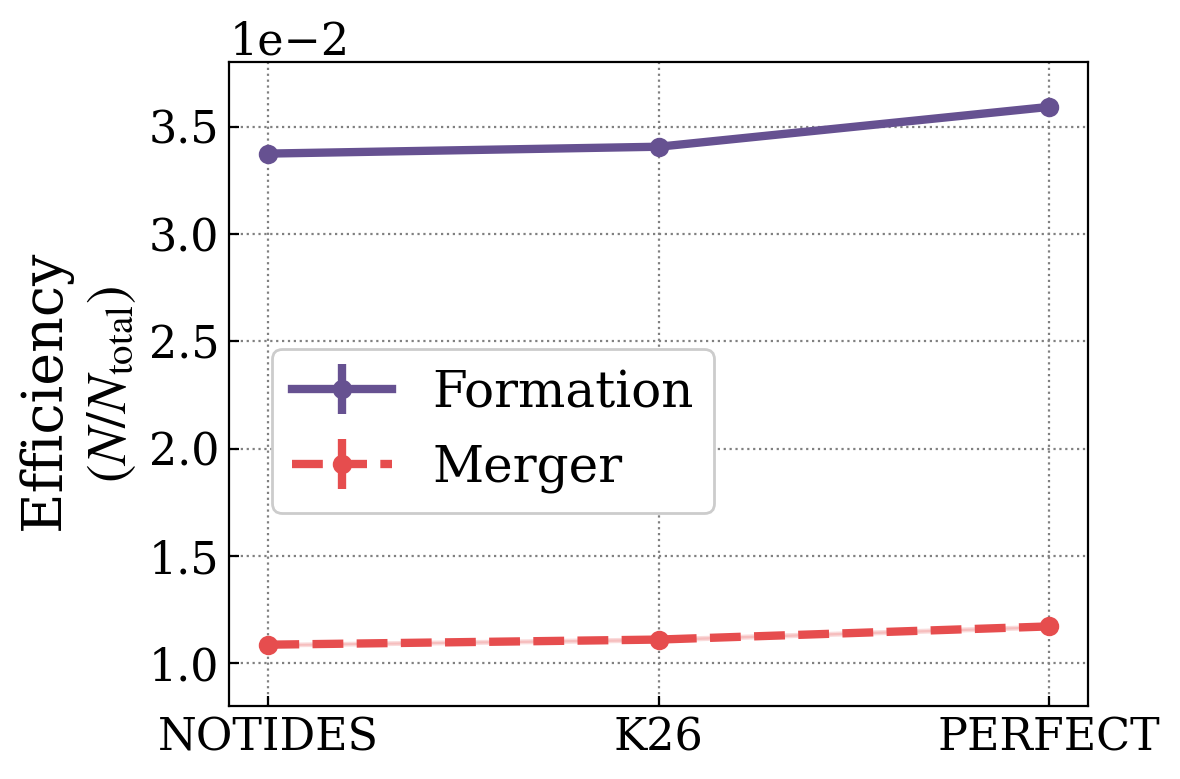

In [71]:
# Plot the rates with error bars
# fig, axes = plt.subplots(ncols=1, nrows=3, figsize=(6, 8))
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 4))

pop_labels_list = [pop_labels[pop_name] for pop_name in pop_names]

# ax = axes[0]
ax.errorbar(pop_labels_list, bbh_formation_rates, yerr=np.array(bbh_formation_errors).T, lw=3, ls='-', marker='o', color=colorPalette['violet'], label='Formation')
ax.errorbar(pop_labels_list, bbh_merger_rates, yerr=np.array(bbh_merger_errors).T, lw=3, ls='--', marker='o', color=colorPalette['red'], label='Merger')
ax.fill_between(pop_labels_list, bbh_formation_rates - np.array(bbh_formation_errors).T[0], bbh_formation_rates + np.array(bbh_formation_errors).T[1], color=colorPalette['violet'], alpha=0.2)
ax.fill_between(pop_labels_list, bbh_merger_rates - np.array(bbh_merger_errors).T[0], bbh_merger_rates + np.array(bbh_merger_errors).T[1], color=colorPalette['red'], alpha=0.2)


ax.set_ylim(0.8e-2, 3.8e-2)

# ax.set_title('BBH')
ax.set_ylabel("Efficiency \n$(N / N_{\mathrm{total}})$", fontsize=20)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
ax.tick_params(axis='both', direction='in')
ax.legend(fontsize=18, loc=(0.05, 0.3))
ax.grid()

# ax = axes[1]
# ax.errorbar(pop_labels_list, bhns_formation_rates, yerr=np.array(bhns_formation_errors).T, lw=3, ls='-', marker='o', color=colorPalette['violet'], label='Formation')
# ax.errorbar(pop_labels_list, bhns_merger_rates, yerr=np.array(bhns_merger_errors).T, lw=3, ls='--', marker='o', color=colorPalette['red'], label='Merger')
# ax.fill_between(pop_labels_list, bhns_formation_rates - np.array(bhns_formation_errors).T[0], bhns_formation_rates + np.array(bhns_formation_errors).T[1], color=colorPalette['violet'], alpha=0.2)
# ax.fill_between(pop_labels_list, bhns_merger_rates - np.array(bhns_merger_errors).T[0], bhns_merger_rates + np.array(bhns_merger_errors).T[1], color=colorPalette['red'], alpha=0.2)
# ax.set_title('BHNS')
# # ax.set_ylim(5e-4, 11e-4)

# ax = axes[2]
# ax.errorbar(pop_labels_list, bns_formation_rates, yerr=np.array(bns_formation_errors).T, lw=3, ls='-', marker='o', color=colorPalette['violet'], label='Formation')
# ax.errorbar(pop_labels_list, bns_merger_rates, yerr=np.array(bns_merger_errors).T, lw=3, ls='--', marker='o', color=colorPalette['red'], label='Merger')
# ax.fill_between(pop_labels_list, bns_formation_rates - np.array(bns_formation_errors).T[0], bns_formation_rates + np.array(bns_formation_errors).T[1], color=colorPalette['violet'], alpha=0.2)
# ax.fill_between(pop_labels_list, bns_merger_rates - np.array(bns_merger_errors).T[0], bns_merger_rates + np.array(bns_merger_errors).T[1], color=colorPalette['red'], alpha=0.2)
# ax.set_title('BNS')
# # ax.set_ylim(0.8e-3, 1.8e-3)


# for ax in axes:
#     ax.grid()
#     # ax.legend(fontsize=18)
#     # ax.set_ylabel("Number of DCOs", fontsize=20)
#     ax.set_ylabel("Efficiency \n$(N / N_{\mathrm{total}})$", fontsize=20)
#     # ax.tick_params(axis='both', which='major', labelsize=20)
#     ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
#     ax.tick_params(axis='both', direction='in')

plt.tight_layout()
plt.savefig(plot_path+'bbh_rates.pdf', dpi=300, bbox_inches='tight')
plt.show()
    

## By Formation Channel

In [66]:
branching_ratios = defaultdict(dict)
print("Formations")
for pop_name in pop_names:
    print(f"Processing: {pop_labels[pop_name]}")
    for i, dco_type in enumerate(dco_types):
        pop_df = pop_dfs[pop_name][(pop_dfs[pop_name]['Stellar_Type(1)'] + pop_dfs[pop_name]['Stellar_Type(2)'] == dco_st[i])]
        # pop_df = pop_df[pop_df['Merges_Hubble_Time']==True]
        
        any_rlof = (pop_df['RLOF_Primary']==True) + (pop_df['RLOF_Secondary']==True) + (pop_df['RLOF_Both']==True)
        any_ce = (pop_df['CE_Primary']==True) + (pop_df['CE_Secondary']==True) +(pop_df['CE_Both']==True)
        any_che = (pop_df['CH_on_MS(1)']==True) + (pop_df['CH_on_MS(2)']==True)

        ce_primary_only = (pop_df['CE_Primary']==True) * (pop_df['CE_Secondary']==False) * (pop_df['CE_Both']==False)
        ce_secondary_only = (pop_df['CE_Primary']==False) * (pop_df['CE_Secondary']==True) * (pop_df['CE_Both']==False)
        ce_both = ((pop_df['CE_Primary']==True) * (pop_df['CE_Secondary']==True)) + (pop_df['CE_Both']==True)
        
        smt = any_rlof * (~any_ce) * (~any_che)
        smt_primary_only = smt * (pop_df['RLOF_Primary']==True) * (pop_df['RLOF_Secondary']==False) * (pop_df['RLOF_Both']==False)
        smt_secondary_only = smt * (pop_df['RLOF_Primary']==False) * (pop_df['RLOF_Secondary']==True) * (pop_df['RLOF_Both']==False)
        smt_both = smt * (((pop_df['RLOF_Primary']==True) * (pop_df['RLOF_Secondary']==True)) + pop_df['RLOF_Both'])
        
        che = any_che * any_rlof


        # Print Results
        print(f"ALL {dco_type}s: {len(pop_df)}")
        print(f"{dco_type}s with RLOF: {np.sum(any_rlof)}")
        print(f"→ {dco_type}s with Stable Mass Transfer: {(np.sum(smt))}")
        print(f"    →→ Primary Only: {np.sum(smt_primary_only)}")
        print(f"    →→ Secondary Only: {(np.sum(smt_secondary_only))}")
        print(f"    →→ Both: {(np.sum(smt_both))}")
        print(f"→ {dco_type}s with Common Envelope: {(np.sum(any_ce))}")
        print(f"    →→ Primary Only: {np.sum(ce_primary_only)}")
        print(f"    →→ Secondary Only: {np.sum(ce_secondary_only)}")
        print(f"    →→ Both: {np.sum(ce_both)}")
        print(f"→ {dco_type}s with Chemically Homogeneous Evolution: {(np.sum(che))}")
        print(f"{dco_type}s with No Mass Transfer: {np.sum(~any_rlof)}")
        print()

        branching_ratios[pop_name][dco_type] = {
            "Total": len(pop_df),
            "No MT": np.sum(~any_rlof),
            "Mass Transfer": {
                "Stable (RLOF)": {
                    "Primary": np.sum(smt_primary_only),
                    "Secondary": np.sum(smt_secondary_only),
                    "Both": np.sum(smt_both)
                },
                "Unstable (CE)": {
                    "Primary": np.sum(ce_primary_only),
                    "Secondary": np.sum(ce_secondary_only),
                    "Both": np.sum(ce_both)
                },
                "CHE" : np.sum(che)
            }
        }

Formations
Processing: NOTIDES
ALL BBHs: 64782
BBHs with RLOF: 64782
→ BBHs with Stable Mass Transfer: 51933
    →→ Primary Only: 0
    →→ Secondary Only: 0
    →→ Both: 51933
→ BBHs with Common Envelope: 12209
    →→ Primary Only: 0
    →→ Secondary Only: 12206
    →→ Both: 3
→ BBHs with Chemically Homogeneous Evolution: 640
BBHs with No Mass Transfer: 0

ALL BHNSs: 4751
BHNSs with RLOF: 4751
→ BHNSs with Stable Mass Transfer: 1955
    →→ Primary Only: 0
    →→ Secondary Only: 0
    →→ Both: 1955
→ BHNSs with Common Envelope: 2795
    →→ Primary Only: 5
    →→ Secondary Only: 2789
    →→ Both: 1
→ BHNSs with Chemically Homogeneous Evolution: 1
BHNSs with No Mass Transfer: 0

ALL BNSs: 941
BNSs with RLOF: 941
→ BNSs with Stable Mass Transfer: 4
    →→ Primary Only: 0
    →→ Secondary Only: 0
    →→ Both: 4
→ BNSs with Common Envelope: 937
    →→ Primary Only: 3
    →→ Secondary Only: 904
    →→ Both: 30
→ BNSs with Chemically Homogeneous Evolution: 0
BNSs with No Mass Transfer: 0

Proc

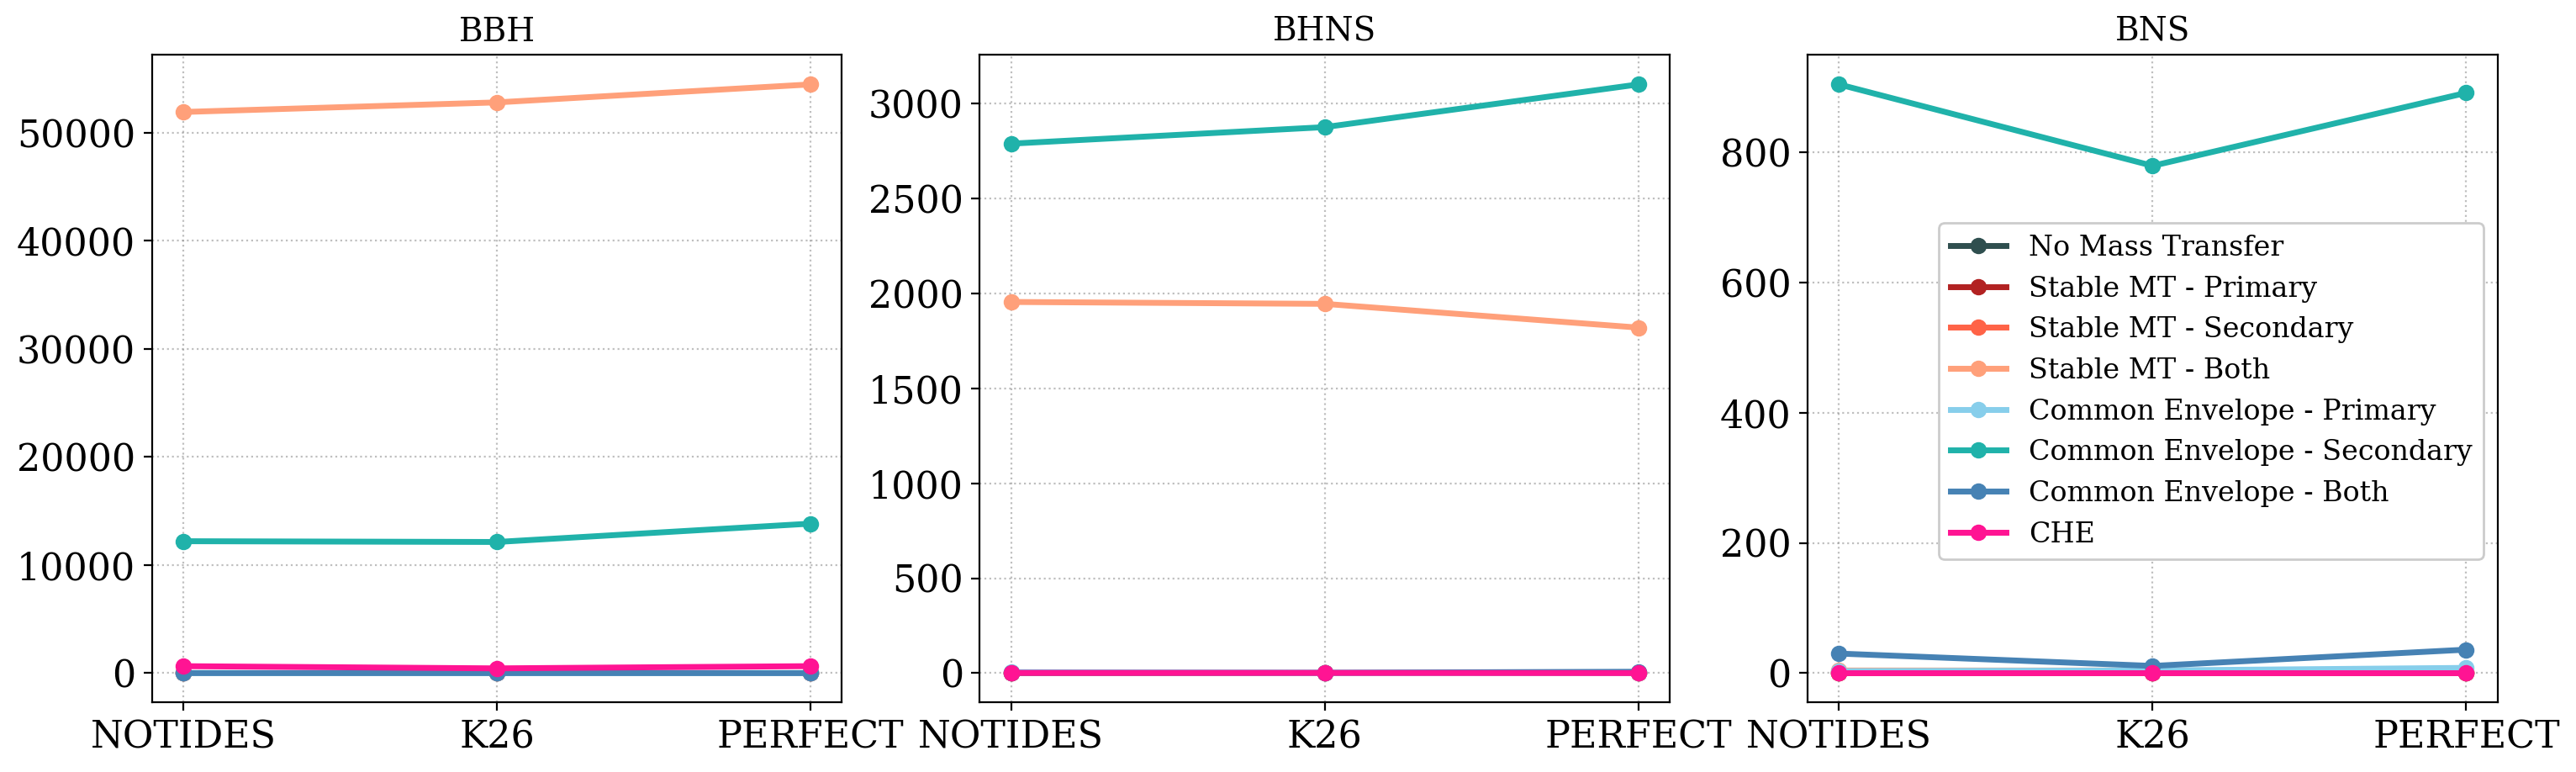

In [67]:
# Given color and label mappings
colors = {
    "No MT": "darkslategray",
    "SMT 1": "firebrick",
    "SMT 2": "tomato",
    "SMT 1+2": "lightsalmon",
    "CE 1": "skyblue",
    "CE 2": "lightseagreen",
    "CE 1+2": "steelblue",
    "CHE" : "deeppink"
}

labels = {
    "Total": "Total DCOs",
    "No MT": "No Mass Transfer",
    "SMT 1": "Stable MT - Primary",
    "SMT 2": "Stable MT - Secondary",
    "SMT 1+2": "Stable MT - Both",
    "CE 1": "Common Envelope - Primary",
    "CE 2": "Common Envelope - Secondary",
    "CE 1+2": "Common Envelope - Both",
    "CHE" : "CHE"
}

# Extract data
# pop_names = list(branching_ratios.keys())
dco_types = list(branching_ratios[pop_names[0]].keys())
dco_linestyles = {"BBH": "-", "BHNS": "-.", "BNS": ':'}


fig, axes = plt.subplots(ncols=3, figsize=(18, 5))

for i, dco_type in enumerate(dco_types):
    # Initialize storage for plotting
    data = {key: [] for key in labels.keys()}
    
    # Collect data across populations
    for pop_name in pop_names:
        data["Total"].append(branching_ratios[pop_name][dco_type]["Total"])
        data["No MT"].append(branching_ratios[pop_name][dco_type]["No MT"])
        data["SMT 1"].append(branching_ratios[pop_name][dco_type]["Mass Transfer"]["Stable (RLOF)"]["Primary"])
        data["SMT 2"].append(branching_ratios[pop_name][dco_type]["Mass Transfer"]["Stable (RLOF)"]["Secondary"])
        data["SMT 1+2"].append(branching_ratios[pop_name][dco_type]["Mass Transfer"]["Stable (RLOF)"]["Both"])
        data["CE 1"].append(branching_ratios[pop_name][dco_type]["Mass Transfer"]["Unstable (CE)"]["Primary"])
        data["CE 2"].append(branching_ratios[pop_name][dco_type]["Mass Transfer"]["Unstable (CE)"]["Secondary"])
        data["CE 1+2"].append(branching_ratios[pop_name][dco_type]["Mass Transfer"]["Unstable (CE)"]["Both"])
        data["CHE"].append(branching_ratios[pop_name][dco_type]["Mass Transfer"]["CHE"])


    # Normalize by total number of DCOs per population
    totals = np.ones_like(np.array([data["Total"]]))
    for key in data.keys():
        data[key] = np.array(data[key]) / totals

    ax = axes[i]
    for key in colors.keys():
        ax.plot([pop_labels[val] for val in pop_names], data[key][0], label=labels[key], color=colors[key], marker="o", linewidth=2.5)

    # Formatting
    ax.set_label("Number of DCO Formations")
    # plt.set_xlabel("Population")
    ax.set_title(dco_type, fontsize=14)
    ax.grid(alpha=0.5)

axes[-1].legend(frameon=True, fontsize=12, loc='lower right', bbox_to_anchor=(1,0.2))
# Show plot
plt.show()


# Mass Spectrum by Formation Channel

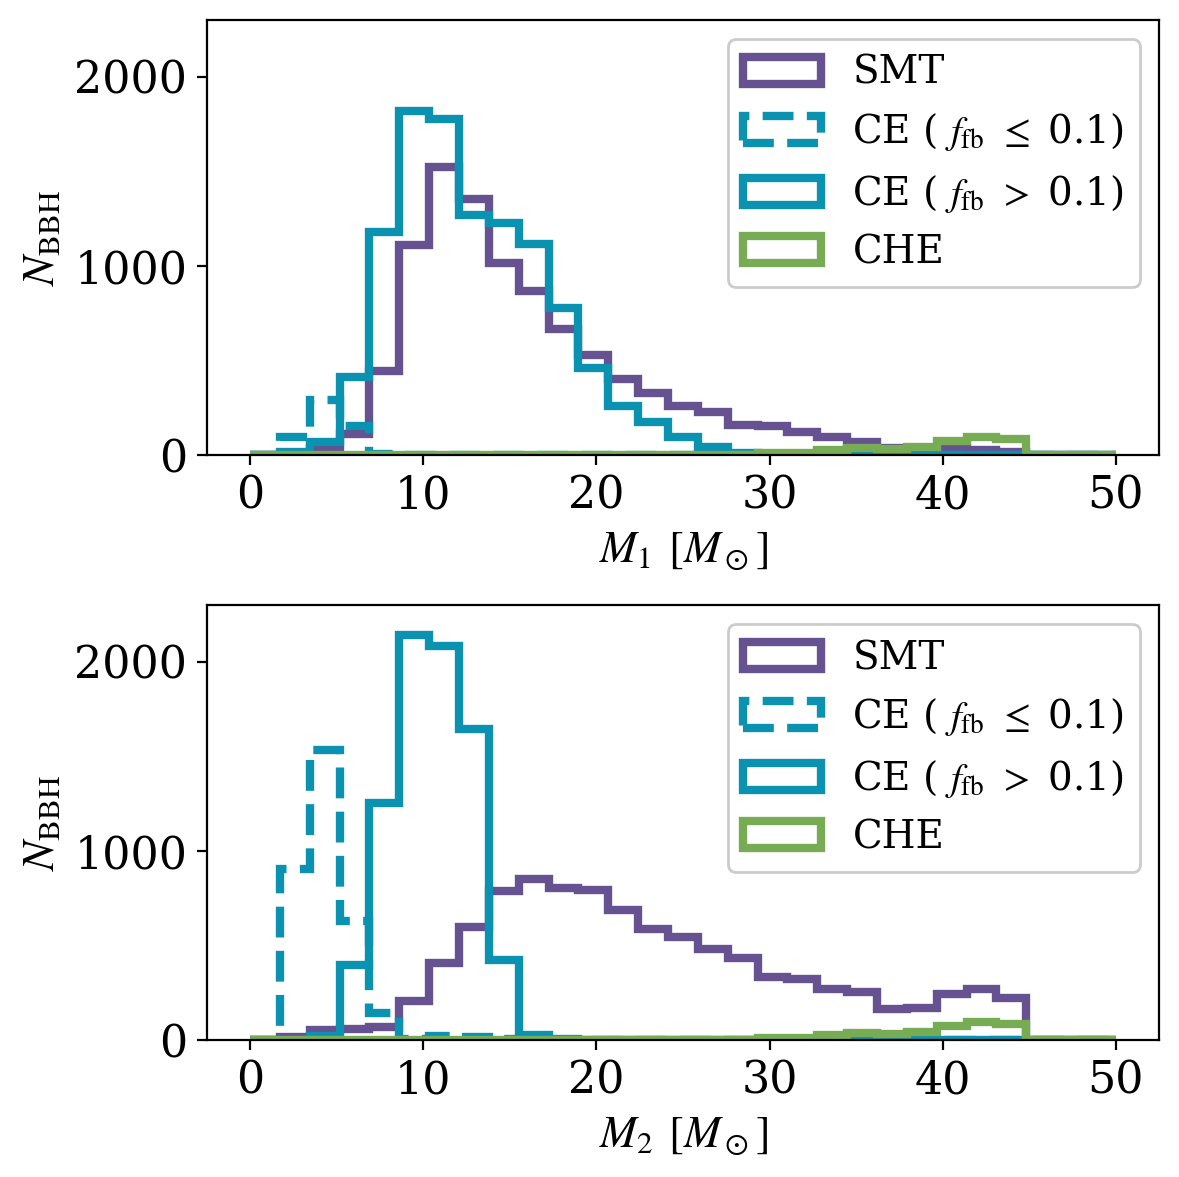

In [ ]:
fig, axes = plt.subplots(ncols=1, nrows=2, figsize=(6, 6), sharex=False)

pop_name = 'realistic'
# pop_name = 'perfect'
dco_type = 'BBH'
pop_df = pop_dfs[pop_name]
pop_df = pop_df[pop_df[dco_type] & pop_df['Merges_Hubble_Time']]

x1 = pop_df['Mass@DCO(1)']
x2 = pop_df['Mass@DCO(2)']

# x1 = pop_df['M_max@DCO']
# x2 = pop_df['M_min@DCO']

bins_x = np.linspace(0, 50, 30)

for i, x in enumerate([x1, x2]):
    ax = axes[i]

    if i==0:
        fb_mask = pop_df['fallback_1'] < 0.1
    else:
        fb_mask = pop_df['fallback_2'] < 0.1
    
    any_rlof = (pop_df['RLOF_Primary']==True) + (pop_df['RLOF_Secondary']==True) + (pop_df['RLOF_Both']==True)
    any_ce = (pop_df['CE_Primary']==True) + (pop_df['CE_Secondary']==True) +(pop_df['CE_Both']==True)
    any_che = (pop_df['CH_on_MS(1)']==True) + (pop_df['CH_on_MS(2)']==True)
    smt_mask = any_rlof * (~any_ce) * (~any_che)
    ce_mask = any_ce * (~any_che)

    ax.hist(x[smt_mask], bins=bins_x, density=False, histtype='step', lw=3, color=colorPalette['violet'], label=r'SMT')
    ax.hist(x[fb_mask & ce_mask], bins=bins_x, density=False, histtype='step', lw=3, color=colorPalette['blue'], ls='--', label=r'CE ( $f_{\rm fb}$ $\leq$ 0.1)')
    ax.hist(x[~fb_mask & ce_mask], bins=bins_x, density=False, histtype='step', lw=3, color=colorPalette['blue'], label=r'CE ( $f_{\rm fb}$ $>$ 0.1)')
    ax.hist(x[any_che], bins=bins_x, density=False, histtype='step', lw=3, color=colorPalette['green'], label=r'CHE')

    ax.legend(fontsize=14)
    ax.set_ylabel(r'$N_{\rm BBH}$')
    ax.set_ylim(0, 2300)

axes[0].set_xlabel('$M_1$ $[M_\odot]$')
axes[1].set_xlabel('$M_2$ $[M_\odot]$')

plt.tight_layout()
# plt.savefig(plot_path+"m1_m2_breakdown_realistic.pdf", dpi=300, bbox_inches='tight')

plt.show()

# Mass-Period by Formation Channel

In [47]:
channel_colors = {'No MT' : colorPalette['red'], 
                  'SMT' : colorPalette['violet'], 
                  'CE' : colorPalette['blue'], 
                  'CHE' : colorPalette['green']}

channel_cmaps = {'No MT' : plt.cm.Reds,
                    'SMT' : plt.cm.Purples,
                    'CE' : plt.cm.Blues,
                    'CHE' : plt.cm.Greens}

/tmp/ipykernel_2302964/1920397025.py:50: RuntimeWarning: divide by zero encountered in log10
  ax.contourf(X, Y, np.log10(hist), cmap=channel_cmaps[channel], alpha=0.7, locator=ticker.MaxNLocator(prune = 'lower'), vmin=1e-4, vmax=2.9)
/tmp/ipykernel_2302964/1920397025.py:83: RuntimeWarning: divide by zero encountered in log10
  ax.contourf(X, Y, np.log10(hist), cmap=channel_cmaps[channel], alpha=0.5, locator=ticker.MaxNLocator(prune = 'lower'), vmin=1e-4, vmax=2.9, hatches=['\\\\'])


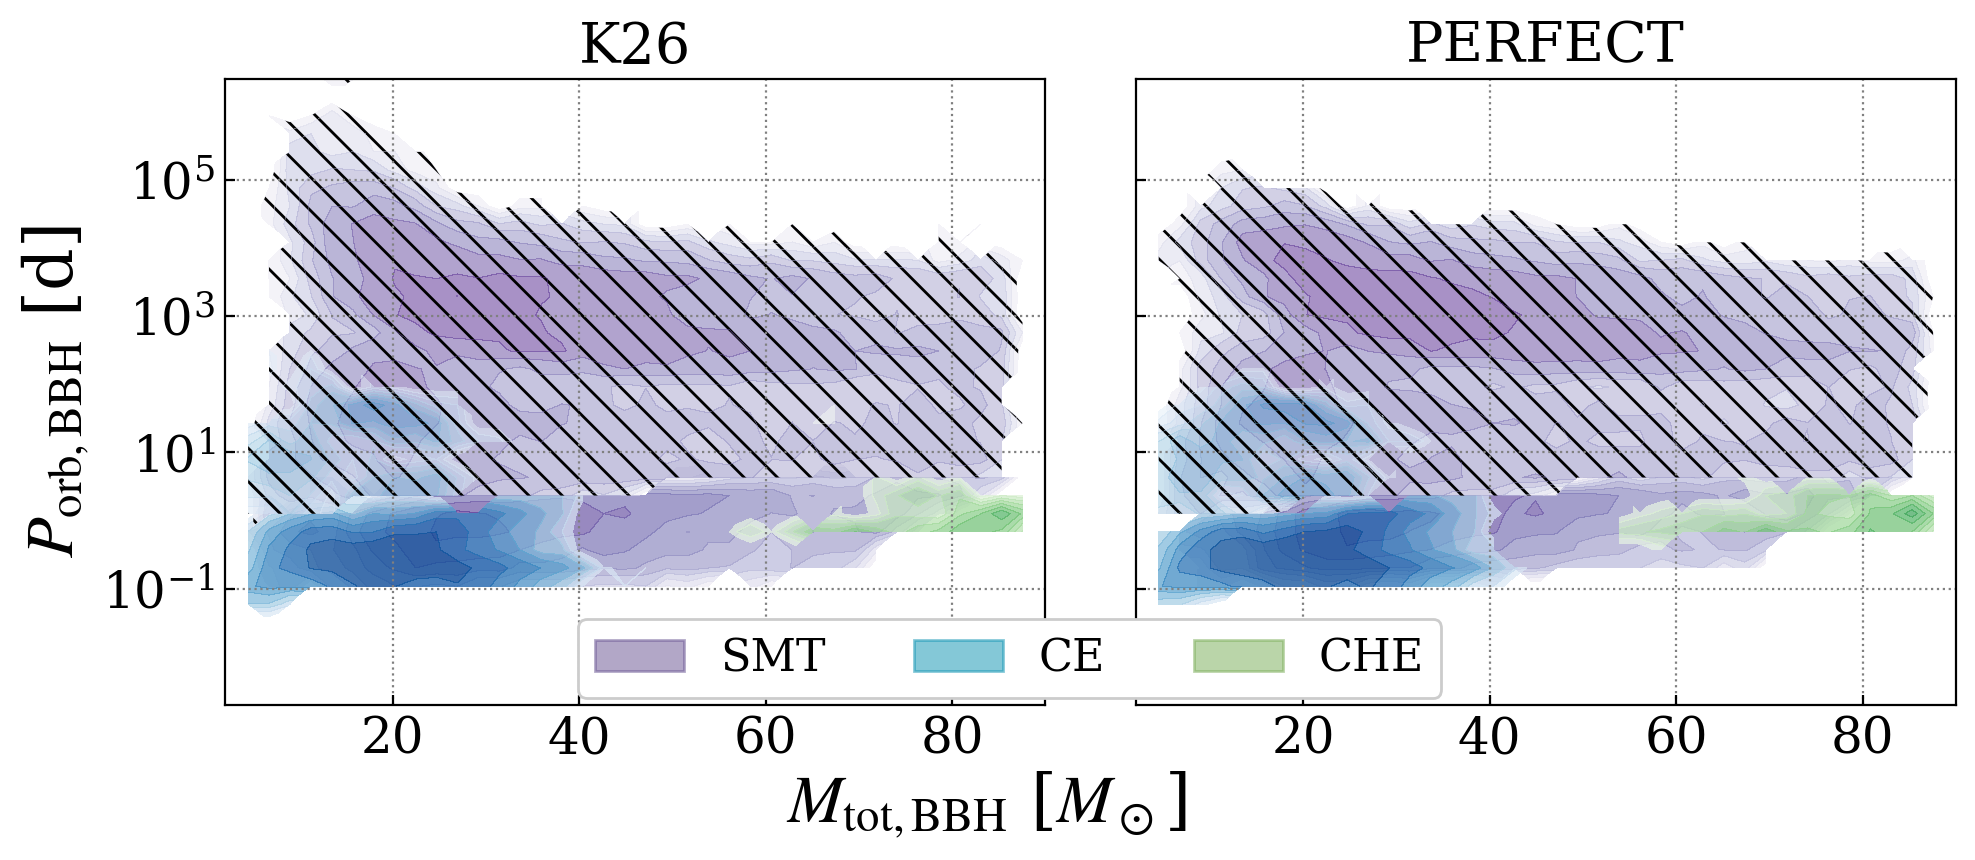

In [54]:
import matplotlib.patches as mpatches

# channels = ['CE', 'SMT', 'CHE', 'No MT']
channels = ['SMT', 'CE', 'CHE']

dco_type = 'BBH'
fig, axes = plt.subplots(ncols=len(pop_names), figsize=(5*len(pop_names), 4), sharey=True)

for i, pop_name in enumerate(pop_names):
    ax = axes[i]
    
    # Define histogram bins
    y_bins = np.logspace(-6, 7, 50)
    x_bins = np.linspace(0, 110, 50)
    # x_bins = np.geomspace(1, 110, 50)
    # y_bins = np.linspace(min(y_vals), max(y_vals), 100)
    
    # Mask for DCO type
    pop_df = pop_dfs[pop_name]
    pop_df = pop_df[pop_df[dco_type]]
    pop_df = pop_df[pop_df['Merges_Hubble_Time']==True]
    
    rlof_mask = pop_df['RLOF_Primary'] | pop_df['RLOF_Secondary'] | pop_df['RLOF_Both']
    ce_mask = pop_df['CE_Primary'] | pop_df['CE_Secondary'] | pop_df['CE_Both']
    che_mask = pop_df['CH_on_MS(1)'] | pop_df['CH_on_MS(2)']
    smt_mask = rlof_mask & ~ce_mask & ~che_mask
    no_mt_mask = ~rlof_mask
    
    channel_masks = {}
    channel_masks['SMT'] = smt_mask
    channel_masks['CE'] = ce_mask
    channel_masks['CHE'] = che_mask
    # channel_masks['No MT'] = no_mt_mask

    for channel in channels:
        mask = channel_masks[channel]
        # Get x and y values
        x_vals = pop_df['Mass@DCO(1)'][mask] + pop_df['Mass@DCO(2)'][mask]
        omega_orb = (np.sqrt(c.G * (pop_df['Mass@DCO(1)'].values + pop_df['Mass@DCO(2)'].values) * u.M_sun / (pop_df['SemiMajorAxis@DCO'].values*u.AU)**3).to(1/u.d))
        y_vals = (2 * np.pi / omega_orb).to(u.d).value[mask]

        

        # Compute 2D histogram
        hist, x_edges, y_edges = np.histogram2d(x_vals, y_vals, bins=[x_bins, y_bins])

        # Plot contours
        X, Y = np.meshgrid(x_edges[:-1], y_edges[:-1], indexing='ij')

        ax.contourf(X, Y, np.log10(hist), cmap=channel_cmaps[channel], alpha=0.7, locator=ticker.MaxNLocator(prune = 'lower'), vmin=1e-4, vmax=2.9) 

        
    pop_df = pop_dfs[pop_name]
    pop_df = pop_df[pop_df[dco_type]]
    pop_df = pop_df[pop_df['Merges_Hubble_Time']==False]
    
    rlof_mask = pop_df['RLOF_Primary'] | pop_df['RLOF_Secondary'] | pop_df['RLOF_Both']
    ce_mask = pop_df['CE_Primary'] | pop_df['CE_Secondary'] | pop_df['CE_Both']
    che_mask = pop_df['CH_on_MS(1)'] | pop_df['CH_on_MS(2)']
    smt_mask = rlof_mask & ~ce_mask & ~che_mask
    no_mt_mask = ~rlof_mask
    
    channel_masks = {}
    channel_masks['SMT'] = smt_mask
    channel_masks['CE'] = ce_mask
    channel_masks['CHE'] = che_mask
    # channel_masks['No MT'] = no_mt_mask

    for channel in channels:
        mask = channel_masks[channel]
        # Get x and y values
        x_vals = pop_df['Mass@DCO(1)'][mask] + pop_df['Mass@DCO(2)'][mask]
        omega_orb = (np.sqrt(c.G * (pop_df['Mass@DCO(1)'].values + pop_df['Mass@DCO(2)'].values) * u.M_sun / (pop_df['SemiMajorAxis@DCO'].values*u.AU)**3).to(1/u.d))
        y_vals = (2 * np.pi / omega_orb).to(u.d).value[mask]


        # Compute 2D histogram
        hist, x_edges, y_edges = np.histogram2d(x_vals, y_vals, bins=[x_bins, y_bins])

        # Plot contours
        X, Y = np.meshgrid(x_edges[:-1], y_edges[:-1], indexing='ij')

        ax.contourf(X, Y, np.log10(hist), cmap=channel_cmaps[channel], alpha=0.5, locator=ticker.MaxNLocator(prune = 'lower'), vmin=1e-4, vmax=2.9, hatches=['\\\\']) 

    ax.set_title(pop_labels[pop_name], fontsize=20)
    # ax.set_xscale('log')
    ax.set_yscale('log')
    
    
    ax.set_xlim(2, 90)
    ax.set_ylim(2e-3, 3e6)
    
    ax.grid()

    legend_patches = [mpatches.Patch(color=channel_colors[channel], label=channel, alpha=0.5) for channel in channels]
    ax.tick_params(axis='both', direction='in', which='both')
    ax.tick_params(axis='both', labelsize=18)
        
axes[0].set_ylabel('$P_{\mathrm{orb, BBH}}$ [d]', fontsize=24)
axes[1].legend(handles=legend_patches, ncols=3, loc='lower right', fontsize=16, bbox_to_anchor=(0.4,-0.025))

fig.text(0.5, -0.04, r'$M_{\mathrm{tot, BBH}}$ [$M_\odot$]', ha='center', fontsize=24)

plt.tight_layout()
fig.subplots_adjust(wspace=0.11)
plt.savefig(plot_path+"mtot_orb_period_dco_dist_formation_channels.pdf", dpi=300, bbox_inches='tight')
plt.show()
